# Analyse exploratoire et préparation des données

## Jeu de données APS Failure at Scania Trucks

Ce carnet constitue le livrable D3. Il couvre l'exigence EF01, analyse
exploratoire, et l'exigence EF02, pipeline de préparation reproductible.

Le jeu de données provient du constructeur suédois Scania et concerne le système
d'air comprimé de ses camions, en anglais Air Pressure System, abrégé APS. Ce
circuit alimente notamment le freinage et l'embrayage.

Un point de vocabulaire évite un malentendu fréquent. Tous les camions du jeu de
données sont déjà en panne et déjà à l'atelier. La question posée n'est pas de
distinguer un camion sain d'un camion défaillant, mais de déterminer si la panne
provient du système d'air comprimé ou d'un autre organe. Une fausse alerte fait
inspecter un circuit sain. Une panne non détectée laisse la vraie cause en place.

Trois difficultés structurent le travail. Les pannes du système d'air comprimé
sont rares, moins de deux pour cent des cas. De nombreuses mesures sont absentes.
Et les deux types d'erreur n'ont pas le même coût, dans un rapport de 50 contre 1.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import COUT_FN, COUT_FP, FIGURES, SEUIL_BAYES, SEUIL_ECART
from src.graines import set_seed

set_seed()
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

print("Environnement prêt")
print(f"Coût d'une fausse alerte : {COUT_FP}")
print(f"Coût d'une panne non détectée : {COUT_FN}")
print(f"Seuil théorique de décision : {SEUIL_BAYES:.4%}")

2026-08-24 17:06:31.787470: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-24 17:06:31.836069: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Environnement prêt
Coût d'une fausse alerte : 10
Coût d'une panne non détectée : 500
Seuil théorique de décision : 1.9608%


In [2]:
from src.donnees import charge

df = charge("train")

print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Pannes APS : {int(df['class'].sum())} "
      f"({df['class'].mean():.4%})")
print(f"Autres pannes : {int((df['class'] == 0).sum())}")
print(f"\nTypes de données : {df.dtypes.value_counts().to_dict()}")

Dimensions : 60000 lignes, 171 colonnes
Pannes APS : 1000 (1.6667%)
Autres pannes : 59000

Types de données : {dtype('float64'): 169, dtype('int64'): 2}


In [3]:
# Les sept variables histogramme du fichier se reconnaissent au préfixe partagé
mesures = [c for c in df.columns if c != "class"]

prefixes = pd.Series([c.rsplit("_", 1)[0] for c in mesures]).value_counts()
histogrammes = prefixes[prefixes >= 10]

print(f"Colonnes de mesure : {len(mesures)}")
print(f"Groupes de dix colonnes de même préfixe : {len(histogrammes)}")
print(f"Colonnes concernées : {int(histogrammes.sum())}")
print(f"Compteurs isolés : {len(mesures) - int(histogrammes.sum())}")
print(f"\nPréfixes des histogrammes : {sorted(histogrammes.index)}")

Colonnes de mesure : 170
Groupes de dix colonnes de même préfixe : 7
Colonnes concernées : 70
Compteurs isolés : 100

Préfixes des histogrammes : ['ag', 'ay', 'az', 'ba', 'cn', 'cs', 'ee']


### Conclusion du bloc 1

Le fichier d'entraînement compte 60 000 lignes et 171 colonnes, dont 170 mesures
de capteurs et une étiquette. Le taux de pannes du système d'air comprimé
s'établit à 1,6667 pour cent, soit 1 000 cas.

Les noms de colonnes sont anonymisés pour raisons de confidentialité
industrielle. Parmi les 170 mesures, 70 forment sept histogrammes de dix
tranches, identifiables par un préfixe partagé. Les 100 restantes sont des
compteurs isolés. Cette distinction sera utile plus loin : elle permet de
vérifier que les colonnes remarquables identifiées dans la suite ne sont pas
simplement les tranches d'une même variable.

## 2. Les valeurs absentes, en volume

Le cahier des charges annonce un taux moyen de valeurs absentes d'environ huit
pour cent. Une moyenne peut masquer deux réalités très différentes : des trous
répartis uniformément, ou une concentration extrême sur quelques colonnes. Le
traitement à appliquer n'est pas le même dans les deux cas.

In [5]:
absences = df[mesures].isna()
taux = absences.mean().sort_values(ascending=False)

print(f"Taux moyen de valeurs absentes : {absences.to_numpy().mean():.2%}")
print(f"Colonnes complètes             : {(taux == 0).sum()}")
print(f"Colonnes au-dessus de 10 %     : {(taux > 0.10).sum()}")
print(f"Colonnes au-dessus de 50 %     : {(taux > 0.50).sum()}")
print(f"Colonnes au-dessus de 65 %     : {(taux > 0.65).sum()}")
print(f"\nLes dix plus incomplètes :")
print(taux.head(10).apply(lambda v: f"{v:.1%}").to_string())

Taux moyen de valeurs absentes : 8.33%
Colonnes complètes             : 1
Colonnes au-dessus de 10 %     : 28
Colonnes au-dessus de 50 %     : 8
Colonnes au-dessus de 65 %     : 8

Les dix plus incomplètes :
br_000    82.1%
bq_000    81.2%
bp_000    79.6%
bo_000    77.2%
cr_000    77.2%
ab_000    77.2%
bn_000    73.3%
bm_000    65.9%
bl_000    45.5%
bk_000    38.4%


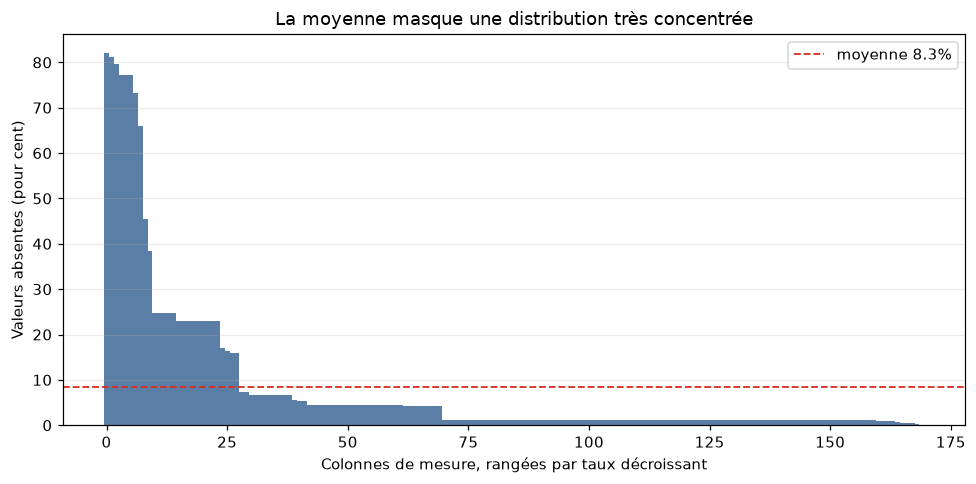

In [6]:
# Figure 1 : la distribution des taux d'absence
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(range(len(taux)), taux.values * 100, width=1.0, color="#5b7ea6")
ax.axhline(absences.to_numpy().mean() * 100, color="#d7301f", ls="--", lw=1.2,
           label=f"moyenne {absences.to_numpy().mean():.1%}")

ax.set_xlabel("Colonnes de mesure, rangées par taux décroissant")
ax.set_ylabel("Valeurs absentes (pour cent)")
ax.set_title("La moyenne masque une distribution très concentrée")
ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES / "f1_distribution_absences.png", dpi=150)
plt.show()

### Conclusion du bloc 2

Le taux moyen de 8,3 pour cent est trompeur. La distribution est fortement
concentrée : huit colonnes dépassent 65 pour cent de valeurs absentes, la plus
touchée atteint 82 pour cent, tandis que la majorité du fichier est presque
complète. Une seule colonne, `aa_000`, ne comporte aucune valeur absente.

Cette concentration écarte l'hypothèse d'une défaillance aléatoire de la chaîne
d'acquisition. Un mécanisme systématique est à l'oeuvre, et il faut le
caractériser avant de décider comment traiter ces trous. C'est l'objet des blocs
suivants.

## 3. Le découpage des données, effectué maintenant

À partir d'ici, l'analyse va mettre en jeu l'étiquette : il s'agit de savoir si
l'absence d'une mesure est liée au type de panne. Cette analyse conduira à
retenir certaines colonnes plutôt que d'autres, et à calculer des quantités,
médianes et paramètres de mise à l'échelle, qui serviront à préparer les données.

Le découpage doit donc intervenir avant, et non après. Dans le cas contraire, le
choix des colonnes retenues et les quantités calculées auraient été influencés
par les lignes réservées à l'évaluation, qui ne pourraient plus jouer leur rôle
de juge indépendant. Cette contamination est appelée fuite d'information, en
anglais data leakage.

Le découpage est stratifié, c'est-à-dire qu'il conserve la même proportion de
pannes de part et d'autre. Cette précaution n'est pas de pure forme sur ce jeu de
données, comme le montre la cellule suivante.

In [8]:
from src.donnees import decoupe

X_app, X_val, y_app, y_val = decoupe()

print(f"Apprentissage : {X_app.shape[0]} lignes, "
      f"{int(y_app.sum())} pannes ({y_app.mean():.4%})")
print(f"Validation    : {X_val.shape[0]} lignes, "
      f"{int(y_val.sum())} pannes ({y_val.mean():.4%})")

# Ce que donnerait un tirage non stratifié, sur 500 essais
rng = np.random.default_rng(42)
y_tout = df["class"].to_numpy()
taux_tirages = np.array([
    y_tout[rng.permutation(len(y_tout))[:12000]].mean() for _ in range(500)
])

print(f"\nSans stratification, sur 500 tirages :")
print(f"  taux de pannes de {taux_tirages.min():.4%} à {taux_tirages.max():.4%}")
print(f"  tirages franchissant le seuil de {SEUIL_BAYES:.4%} : "
      f"{(taux_tirages > SEUIL_BAYES).sum()} sur 500")

Apprentissage : 48000 lignes, 800 pannes (1.6667%)
Validation    : 12000 lignes, 200 pannes (1.6667%)

Sans stratification, sur 500 tirages :
  taux de pannes de 1.3583% à 1.9833%
  tirages franchissant le seuil de 1.9608% : 2 sur 500


### Conclusion du bloc 3

Le fichier d'entraînement est scindé en 48 000 lignes d'apprentissage et 12 000
lignes de validation, avec une graine aléatoire fixée à 42 pour garantir la
reproductibilité.

La stratification a une conséquence particulière sur ce jeu de données. Le seuil
de décision théorique de 1,9608 pour cent est aussi le taux de pannes au-delà
duquel la règle naïve la moins coûteuse change : en dessous, il vaut mieux ne
rien signaler ; au-dessus, il vaut mieux tout signaler. Le fichier étant à
1,6667 pour cent, juste en dessous de cette frontière, un tirage non stratifié
malchanceux produirait une partie de validation située de l'autre côté, donc dans
un régime de décision différent de celui de l'apprentissage. La stratification
n'est donc pas une précaution de forme mais une condition de cohérence.

Toutes les analyses suivantes portent sur les 48 000 lignes d'apprentissage. Les
12 000 lignes de validation ne sont plus consultées, et le jeu de test officiel
reste fermé.

## 4. L'absence d'une mesure est-elle liée au type de panne

Deux hypothèses s'opposent. Selon la première, une valeur absente est une
information perdue : il faut la remplacer au mieux et passer à autre chose.
Selon la seconde, l'absence est elle-même une observation : si un capteur ne
remonte rien, c'est peut-être parce que le sous-système concerné se trouve dans
un état particulier.

Ces deux hypothèses conduisent à des traitements opposés. La première justifie
une imputation simple, voire la suppression des colonnes les plus incomplètes.
La seconde impose au contraire de conserver la trace de ce qui manquait.

La méthode retenue pour trancher consiste à mesurer, pour chaque colonne, le taux
d'absence dans chacune des deux classes, puis à examiner l'écart. Une colonne
dont l'absence ne dit rien présente le même taux des deux côtés. Une colonne dont
l'absence est informative présente un écart marqué.

Le seuil de 10 points d'écart retenu pour la sélection est un choix, arrêté avant
le calcul. Il ne correspond à aucune discontinuité naturelle dans les données, et
il est assumé comme tel plus loin dans ce carnet.

In [9]:
from src.absences import taux_par_classe, detecte_groupes

t = taux_par_classe(X_app, y_app)
t["ecart"] = t["taux_autres"] - t["taux_aps"]

print("Les huit colonnes les plus absentes chez les autres pannes :")
print((t.sort_values("ecart", ascending=False).head(8) * 100).round(1).to_string())

print("\nLes huit colonnes les plus absentes chez les pannes APS :")
print((t.sort_values("ecart").head(8) * 100).round(1).to_string())

Les huit colonnes les plus absentes chez les autres pannes :
        taux_aps  taux_autres  ecart
br_000       9.2         83.4   74.1
bq_000       8.9         82.5   73.7
bp_000       8.4         80.9   72.5
bo_000       7.9         78.6   70.7
bn_000       7.6         74.7   67.0
bm_000       7.4         67.1   59.8
bl_000       7.0         46.2   39.2
bk_000       6.6         39.0   32.3

Les huit colonnes les plus absentes chez les pannes APS :
        taux_aps  taux_autres  ecart
di_000      51.7          5.9  -45.8
dh_000      51.7          5.9  -45.8
dl_000      51.7          5.9  -45.8
dk_000      51.7          5.9  -45.8
dj_000      51.7          5.9  -45.8
eb_000      51.7          5.9  -45.8
dm_000      51.7          5.9  -45.8
dg_000      51.7          5.9  -45.8


In [12]:
groupes = detecte_groupes(X_app, y_app, seuil=SEUIL_ECART)

print(f"Seuil de sélection retenu : {SEUIL_ECART:.0%} d'écart")
print(f"\nGroupe 1, absentes chez les AUTRES pannes : "
      f"{len(groupes['groupe1'])} colonnes")
print(f"  {groupes['groupe1']}")
print(f"\nGroupe 2, absentes chez les pannes APS   : "
      f"{len(groupes['groupe2'])} colonnes")
print(f"\nColonnes muettes                          : "
      f"{len(groupes['muettes'])} colonnes")
print(f"\nTotal : {len(groupes['groupe1']) + len(groupes['groupe2']) + len(groupes['muettes'])}")

Seuil de sélection retenu : 10% d'écart

Groupe 1, absentes chez les AUTRES pannes : 8 colonnes
  ['bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000']

Groupe 2, absentes chez les pannes APS   : 56 colonnes

Colonnes muettes                          : 106 colonnes

Total : 170


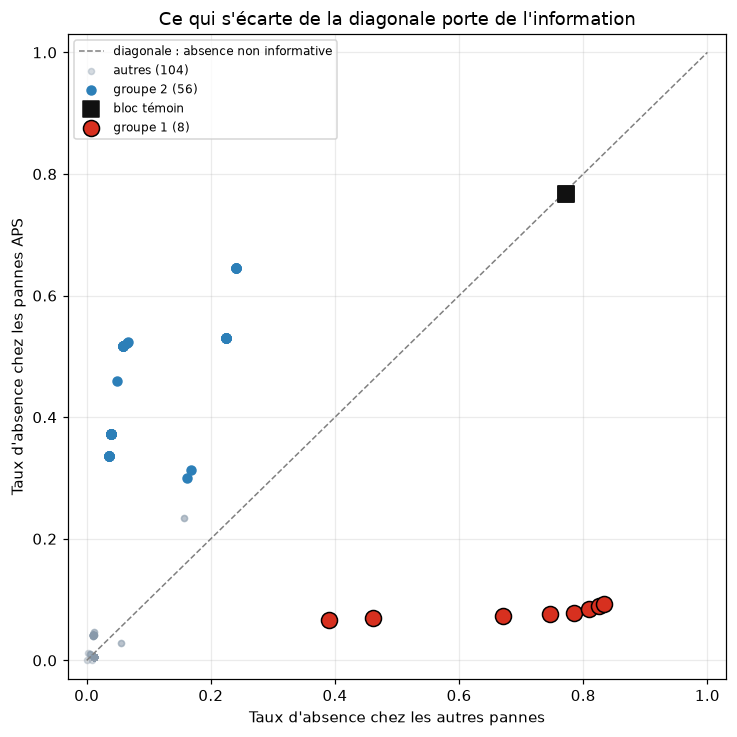

In [13]:
# Figure 2 : le nuage par classe. Chaque point est une colonne.
g1, g2 = groupes["groupe1"], groupes["groupe2"]
temoin = ["ab_000", "cr_000"]
autres = [c for c in X_app.columns if c not in g1 + g2 + temoin]

fig, ax = plt.subplots(figsize=(6.8, 6.8))

ax.plot([0, 1], [0, 1], "--", color="grey", lw=1,
        label="diagonale : absence non informative")
ax.scatter(t.loc[autres, "taux_autres"], t.loc[autres, "taux_aps"],
           s=16, alpha=0.35, color="#8899aa", label=f"autres ({len(autres)})")
ax.scatter(t.loc[g2, "taux_autres"], t.loc[g2, "taux_aps"],
           s=34, color="#2c7fb8", label=f"groupe 2 ({len(g2)})")
ax.scatter(t.loc[temoin, "taux_autres"], t.loc[temoin, "taux_aps"],
           s=110, marker="s", color="#111111", zorder=3, label="bloc témoin")
ax.scatter(t.loc[g1, "taux_autres"], t.loc[g1, "taux_aps"],
           s=110, color="#d7301f", edgecolor="black", zorder=3,
           label=f"groupe 1 ({len(g1)})")

ax.set_xlabel("Taux d'absence chez les autres pannes")
ax.set_ylabel("Taux d'absence chez les pannes APS")
ax.set_title("Ce qui s'écarte de la diagonale porte de l'information")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES / "f2_nuage_par_classe.png", dpi=150)
plt.show()

In [14]:
# Le seuil de 10 points est-il justifié par une discontinuité ?
ecarts_tries = groupes["ecart"].abs().sort_values(ascending=False)

print("Les vingt-cinq plus grands écarts absolus :")
print(np.round(ecarts_tries.head(25).values, 3))

print(f"\nColonnes au-dessus de 5 points  : {(ecarts_tries > 0.05).sum()}")
print(f"Colonnes au-dessus de 10 points : {(ecarts_tries > 0.10).sum()}")
print(f"Colonnes au-dessus de 20 points : {(ecarts_tries > 0.20).sum()}")


Les vingt-cinq plus grands écarts absolus :
[0.741 0.737 0.725 0.707 0.67  0.598 0.458 0.458 0.458 0.458 0.458 0.458
 0.458 0.458 0.458 0.458 0.458 0.41  0.404 0.404 0.404 0.404 0.404 0.392
 0.333]

Colonnes au-dessus de 5 points  : 66
Colonnes au-dessus de 10 points : 64
Colonnes au-dessus de 20 points : 62


### Conclusion du bloc 4

Sur les 170 colonnes de mesure, 64 présentent un écart de taux d'absence entre
classes supérieur à 10 points, soit 37,6 pour cent du fichier. Ces colonnes se
répartissent en deux groupes de sens opposés.

Le premier groupe compte huit colonnes, de `bk_000` à `br_000`. Elles sont
absentes chez la grande majorité des autres pannes mais presque toujours
présentes chez les pannes du système d'air comprimé, avec un écart atteignant
74 points sur la plus marquée.

Le second groupe compte 56 colonnes et présente le comportement inverse, avec des
écarts de 40 à 47 points.

Les 106 colonnes restantes sont muettes : leur taux d'absence est
sensiblement le même dans les deux classes.

Une réserve doit être portée sur la méthode. Le classement des écarts ne présente
aucune discontinuité franche : il s'agit d'un continuum. Le seuil de 10 points ne
sépare donc pas deux populations naturellement distinctes, et il constitue un
choix. Ce choix reste défendable pour une raison plus modeste mais réelle : il a
été arrêté avant le calcul. La sensibilité de la sélection à ce seuil est
mesurée en cellule 19 et sera rapportée.

La conclusion opérationnelle est que l'information portée par les absences ne
peut pas être écartée. La suite du carnet cherche à comprendre par quel mécanisme
elle est produite.

## 5. La structure interne du premier groupe

Huit colonnes informatives peuvent se traduire par huit variables indicatrices
binaires, valant 1 lorsque la mesure est absente. Cette solution est coûteuse en
dimensions et elle ignore une éventuelle structure.

La question posée est celle du nombre de configurations d'absence réellement
observées. Huit colonnes autorisent 256 combinaisons. Si toutes apparaissent, les
absences sont indépendantes et huit indicatrices sont nécessaires. Si très peu
apparaissent, un mécanisme déterministe est à l'oeuvre et un résumé plus compact
existe.

Un cas particulier mérite attention : l'emboîtement. Les absences sont dites
emboîtées lorsque les colonnes s'éteignent toujours dans le même ordre, de sorte
qu'une colonne absente implique l'absence de toutes les suivantes. Une telle
structure produit exactement neuf configurations pour huit colonnes, et se résume
alors à un seul entier compris entre 0 et 8, appelé profondeur.

Une précaution s'impose ici. Compter neuf configurations ne démontre pas
l'emboîtement : neuf configurations quelconques donnent le même compte, et il
existe plus de onze millions de milliards de façons d'en choisir neuf parmi 256.
La vérification porte donc sur la forme des configurations et non sur leur
nombre.

In [15]:
from src.absences import test_emboitement

emb = test_emboitement(X_app, g1)

print(f"Colonnes rangées par taux d'absence croissant : {g1}")
print(f"\nConfigurations observées : {emb['n_motifs']} sur {emb['n_possibles']}")
print(f"Lignes emboîtées         : {emb['part_emboitee']:.4%}")
print(f"\nDétail des configurations, 1 signifie absente :")
print(emb["effectifs"].to_string())

Colonnes rangées par taux d'absence croissant : ['bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000']

Configurations observées : 9 sur 256
Lignes emboîtées         : 100.0000%

Détail des configurations, 1 signifie absente :
11111111    18445
00111111     9901
00000000     8562
00011111     3555
01111111     3400
00001111     1845
00000111     1098
00000011      781
00000001      413


In [16]:
# Vérification : ce ne sont pas les tranches d'un même histogramme
prefixes_g1 = sorted({c.rsplit("_", 1)[0] for c in g1})
print(f"Préfixes distincts dans le groupe 1 : {len(prefixes_g1)} sur {len(g1)}")
print(f"  {prefixes_g1}")


Préfixes distincts dans le groupe 1 : 8 sur 8
  ['bk', 'bl', 'bm', 'bn', 'bo', 'bp', 'bq', 'br']


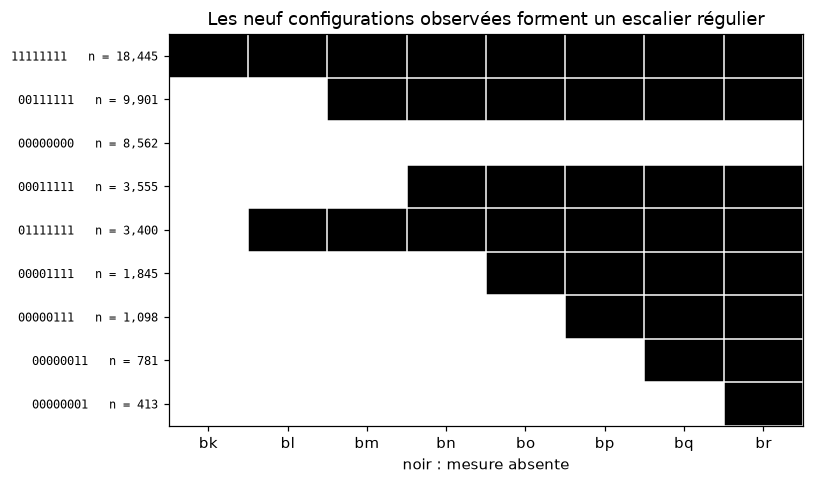

In [17]:
# Figure 3 : les configurations d'absence, vues comme un escalier
motifs = X_app[g1].isna().astype(int).astype(str).agg("".join, axis=1)
compte = motifs.value_counts()
grille = np.array([[int(x) for x in m] for m in compte.index])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.imshow(grille, cmap="Greys", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(g1)))
ax.set_xticklabels([c.replace("_000", "") for c in g1])
ax.set_yticks(range(len(compte)))
ax.set_yticklabels([f"{m}   n = {n:,}" for m, n in compte.items()],
                   fontsize=8, family="monospace")
ax.set_xlabel("noir : mesure absente")
ax.set_title("Les neuf configurations observées forment un escalier régulier")

for i in range(len(compte) + 1):
    ax.axhline(i - 0.5, color="white", lw=1)
for j in range(len(g1) + 1):
    ax.axvline(j - 0.5, color="white", lw=1)

fig.tight_layout()
fig.savefig(FIGURES / "f3_emboitement.png", dpi=150)
plt.show()

### Conclusion du bloc 5

Les huit colonnes du premier groupe présentent un emboîtement parfait. Neuf
configurations d'absence sont observées sur 256 possibles, et la totalité des
48 000 lignes respecte la structure, sans une seule exception.

Les huit colonnes portent des préfixes tous distincts, ce qui écarte l'hypothèse
selon laquelle il s'agirait des tranches d'une même variable histogramme. Ce sont
huit capteurs différents, ce qui rend l'emboîtement parfait d'autant plus
remarquable.

Conséquence pratique retenue en décision D-09 : les huit indicatrices binaires
seraient strictement redondantes entre elles. Une seule variable ordinale,
nommée `profondeur_g1` et valant le nombre de colonnes absentes, porte
exactement la même information. Huit colonnes se réduisent à un entier.

## 6. Un point de comparaison interne au fichier

L'argument développé jusqu'ici serait fragile s'il reposait uniquement sur la
comparaison du premier groupe au reste du fichier. Il est renforcé par
l'existence, dans le même fichier, d'un exemple avéré d'absence non informative.

Les colonnes `ab_000` et `cr_000` présentent un taux d'absence élevé et une
corrélation d'absence parfaite : elles manquent exactement sur les mêmes lignes.
Elles constituent donc un bloc au même titre que le premier groupe. La différence
tient à leur écart entre classes, qui est nul.

In [18]:
for c in temoin:
    print(f"{c} : absente {X_app[c].isna().mean():.1%} du temps, "
          f"écart entre classes {t.loc[c, 'ecart']:+.4f}")

correlation = X_app[temoin].isna().astype(int).corr().iloc[0, 1]
print(f"\nCorrélation d'absence entre les deux colonnes : {correlation:.6f}")

print(f"\nÀ comparer au groupe 1 :")
print(f"  taux d'absence moyen : {X_app[g1].isna().mean().mean():.1%}")
print(f"  écart entre classes  : de {t.loc[g1, 'ecart'].min():+.3f} "
      f"à {t.loc[g1, 'ecart'].max():+.3f}")

ab_000 : absente 77.1% du temps, écart entre classes +0.0040
cr_000 : absente 77.1% du temps, écart entre classes +0.0040

Corrélation d'absence entre les deux colonnes : 1.000000

À comparer au groupe 1 :
  taux d'absence moyen : 68.0%
  écart entre classes  : de +0.323 à +0.741


### Conclusion du bloc 6

Les colonnes `ab_000` et `cr_000` présentent une corrélation d'absence de
1,000000, un taux d'absence de 77 pour cent, et un écart entre classes
inférieur au millième. Elles fournissent, à l'intérieur même du fichier, un
exemple de ce à quoi ressemble une absence massive mais non informative.

Le premier groupe ne lui ressemble pas.

Une conséquence générale s'en dégage, contraire à une pratique courante : un taux
d'absence élevé ne dit rien de la valeur informative d'une colonne. Deux des
colonnes les plus incomplètes du fichier sont muettes, et deux colonnes
informatives ne figurent pas parmi les plus incomplètes. La règle usuelle
consistant à supprimer les colonnes au-delà d'un certain taux d'absence est donc
explicitement écartée dans ce projet, et l'écart en est mesuré au bloc 9.

## 7. La structure du second groupe

Le second groupe compte 56 colonnes. Un test d'emboîtement appliqué à l'ensemble
n'aurait pas de sens : il exigerait que ces 56 colonnes s'éteignent dans un ordre
unique et fixe, ce que rien ne justifie.

L'examen des taux d'absence montre en effet qu'ils ne forment pas un continuum
mais des paliers nets. Le second groupe n'est pas un bloc, c'est un assemblage de
sous-blocs. La procédure retenue consiste à regrouper les colonnes par taux
d'absence arrondi, puis à examiner chaque sous-bloc séparément.

In [19]:
from src.absences import sous_blocs

blocs2 = sous_blocs(X_app, g2)

print(f"Sous-blocs identifiés : {len(blocs2)}\n")
for niveau, membres in sorted(blocs2.items()):
    print(f"  palier {niveau:.3f} : {len(membres):>2} colonnes")

Sous-blocs identifiés : 9

  palier 0.041 :  8 colonnes
  palier 0.045 : 20 colonnes
  palier 0.055 :  1 colonnes
  palier 0.067 :  9 colonnes
  palier 0.073 :  2 colonnes
  palier 0.164 :  1 colonnes
  palier 0.170 :  1 colonnes
  palier 0.230 :  9 colonnes
  palier 0.247 :  5 colonnes


In [20]:
# Chaque sous-bloc est-il homogène ?
print(f"{'palier':>8} {'colonnes':>9} {'configurations':>15} {'verdict':>14}")
print("-" * 50)

for niveau, membres in sorted(blocs2.items()):
    if len(membres) < 2:
        print(f"{niveau:>8.3f} {len(membres):>9} {'colonne seule':>15} "
              f"{'sans objet':>14}")
        continue
    m = X_app[membres].isna().astype(int).astype(str).agg("".join, axis=1)
    n = m.nunique()
    verdict = "homogène" if n <= 2 else "structure interne"
    print(f"{niveau:>8.3f} {len(membres):>9} {n:>15} {verdict:>14}")

  palier  colonnes  configurations        verdict
--------------------------------------------------
   0.041         8               9 structure interne
   0.045        20               9 structure interne
   0.055         1   colonne seule     sans objet
   0.067         9               5 structure interne
   0.073         2               4 structure interne
   0.164         1   colonne seule     sans objet
   0.170         1   colonne seule     sans objet
   0.230         9               2       homogène
   0.247         5               2       homogène


### Conclusion du bloc 7

Le second groupe se décompose en neuf sous-blocs, identifiés par leur taux
d'absence. Trois d'entre eux ne comptent qu'une colonne. Parmi les six restants,
deux sont parfaitement homogènes, c'est-à-dire que leurs colonnes sont absentes
exactement sur les mêmes lignes. Les autres présentent une structure interne.

La décision D-09 retient une indicatrice binaire par sous-bloc, soit neuf
variables au lieu de cinquante-six. Ce résumé est exact pour les sous-blocs
homogènes et approché pour les autres. L'indicatrice est définie par règle
majoritaire, c'est-à-dire qu'elle vaut 1 lorsque la majorité des colonnes du
sous-bloc sont absentes. Cette définition a été préférée au choix d'une colonne
représentative, qui aurait fait dépendre la variable de l'ordre des colonnes.

La perte d'information consentie par ce résumé est mesurable, et elle est mesurée
au bloc 9 par comparaison avec une variante conservant une indicatrice par
colonne.

En résumé, 64 colonnes informatives se réduisent à 10 variables construites : une
variable ordinale de profondeur pour le premier groupe, et neuf indicatrices pour
les sous-blocs du second.

## 8. Par quel mécanisme ces absences sont-elles produites

Savoir que l'absence porte de l'information ne suffit pas. Il reste à comprendre
d'où vient cette information, pour deux raisons.

La première est méthodologique. Si le motif d'absence était produit par la chaîne
de préparation du jeu de données à partir du diagnostic lui-même, il
constituerait une fuite d'information et un modèle qui s'en sert n'aurait aucune
valeur pratique.

La seconde est industrielle. Un signal produit à bord du véhicule pendant son
exploitation est disponible avant l'entrée à l'atelier, donc exploitable en
maintenance prédictive. Un signal produit à l'atelier ne l'est pas.

Quatre lectures ont été envisagées. Un équipement présent sur certains camions
seulement. Des compteurs embarqués se remplissant avec l'usage. Un artefact de
procédure d'atelier. Un artefact de la chaîne de construction du jeu de données.

Une observation permet de les départager. Une seule colonne du fichier est
complète, `aa_000`. Si le motif d'absence était lié à une grandeur physiquement
mesurée sur le camion, cette colonne devrait en porter la trace. L'examen est
conduit à classe constante, chez les autres pannes uniquement, afin que le
résultat ne soit pas un simple reflet de l'étiquette.

In [21]:
from src.absences import profondeur

prof = profondeur(X_app, g1)
non_aps = y_app == 0

table = pd.DataFrame({
    "mediane_aa_000": X_app.loc[non_aps, "aa_000"].groupby(prof[non_aps]).median(),
    "effectif": prof[non_aps].value_counts().sort_index(),
})
table.index.name = "profondeur"

print("Médiane de aa_000 selon la profondeur, chez les autres pannes :\n")
print(table.to_string(float_format=lambda v: f"{v:,.0f}"))

extremes = table["mediane_aa_000"]
print(f"\nFacteur entre les extrêmes : "
      f"{extremes.max() / extremes.min():.0f}")
print(f"Décroissance monotone de la profondeur 1 à 8 : "
      f"{bool((extremes.loc[1:].diff().dropna() < 0).all())}")

Médiane de aa_000 selon la profondeur, chez les autres pannes :

            mediane_aa_000  effectif
profondeur                          
0                   61,159      7836
1                  120,029       410
2                  113,942       777
3                   87,037      1094
4                   77,096      1843
5                   56,354      3553
6                   40,225      9898
7                   29,888      3397
8                      366     18392

Facteur entre les extrêmes : 328
Décroissance monotone de la profondeur 1 à 8 : True


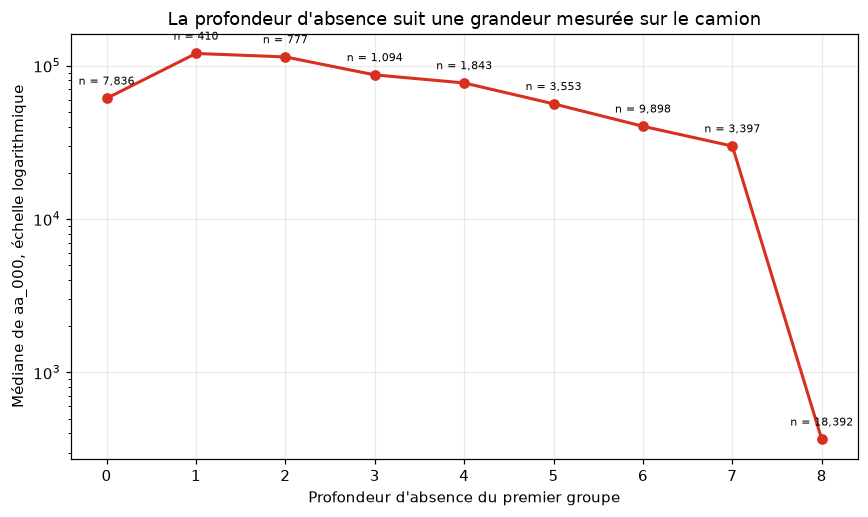

In [22]:
# Figure 4 : la relation entre profondeur d'absence et variable complète
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(table.index, table["mediane_aa_000"], "o-", color="#d7301f", lw=2)
for p, v, n in zip(table.index, table["mediane_aa_000"], table["effectif"]):
    ax.annotate(f"n = {n:,}", (p, v), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=7)

ax.set_yscale("log")
ax.set_xlabel("Profondeur d'absence du premier groupe")
ax.set_ylabel("Médiane de aa_000, échelle logarithmique")
ax.set_title("La profondeur d'absence suit une grandeur mesurée sur le camion")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES / "f4_profondeur_usage.png", dpi=150)
plt.show()

In [23]:
# La distribution de la profondeur diffère-t-elle selon la classe ?
repartition = pd.crosstab(prof, y_app, normalize="columns") * 100
repartition.columns = ["autres pannes", "pannes APS"]
repartition.index.name = "profondeur"

print("Répartition de la profondeur, en pour cent de chaque classe :\n")
print(repartition.round(1).to_string())

intermediaires = repartition.loc[1:7].sum()
print(f"\nProfondeurs intermédiaires, de 1 à 7 :")
print(f"  autres pannes : {intermediaires['autres pannes']:.1f} pour cent")
print(f"  pannes APS    : {intermediaires['pannes APS']:.1f} pour cent")

Répartition de la profondeur, en pour cent de chaque classe :

            autres pannes  pannes APS
profondeur                           
0                    16.6        90.8
1                     0.9         0.4
2                     1.6         0.5
3                     2.3         0.5
4                     3.9         0.2
5                     7.5         0.2
6                    21.0         0.4
7                     7.2         0.4
8                    39.0         6.6

Profondeurs intermédiaires, de 1 à 7 :
  autres pannes : 44.4 pour cent
  pannes APS    : 2.6 pour cent


### Conclusion du bloc 8

La médiane de `aa_000` décroît de façon monotone lorsque la profondeur d'absence
augmente, de près de 120 000 à environ 360, soit un facteur voisin de 329. Cette
mesure est établie à classe constante, elle ne reflète donc pas l'étiquette.

La lecture retenue est celle des compteurs embarqués. Les huit colonnes du
premier groupe seraient des compteurs qui se remplissent avec l'usage du
véhicule. Un camion peu sollicité n'a rien accumulé et ses compteurs restent
vides, ce qui produit une profondeur élevée. À mesure que l'usage s'accumule, les
compteurs s'activent l'un après l'autre, ce qui explique l'emboîtement parfait.
La variable `aa_000` est très probablement un compteur d'usage, kilométrage ou
heures de fonctionnement, et le motif d'absence en est une seconde expression.

Cette lecture affaiblit fortement l'hypothèse d'un artefact de construction du
jeu de données : un traitement automatisé fabriqué à partir du diagnostic n'a
aucune raison de reproduire une mesure physique sur un facteur 329.

Deux observations restent sans explication et sont documentées comme telles. La
profondeur 0 se situe hors de la tendance, ce qui suggère un mélange de deux
populations. Et les profondeurs intermédiaires sont presque absentes chez les
pannes du système d'air comprimé, qui se concentrent aux deux extrêmes.

Une limite doit être énoncée en soutenance. Le signal principal se ramenant à un
indicateur d'usure, il ne s'agit pas d'une fuite d'information, mais le modèle
se rapproche d'une maintenance systématique fondée sur l'usage plutôt que d'une
maintenance véritablement prédictive.

La documentation du constructeur sur l'origine de ces compteurs n'étant pas
publique, les quatre lectures sont portées en soutenance sans être tranchées
définitivement.

## 9. La préparation des données

La chaîne de préparation comporte trois opérations, appliquées dans cet ordre.

L'information portée par les absences est d'abord extraite, avant toute
imputation, faute de quoi elle serait détruite. Le tableau passe de 170 à 180
colonnes.

Les valeurs manquantes sont ensuite imputées de façon différenciée. Les huit
colonnes du premier groupe reçoivent la valeur zéro, les 172 autres la médiane de
leur colonne.

Les 170 colonnes de mesure sont enfin centrées et réduites. La variable de
profondeur et les neuf indicatrices ne le sont pas.

Toutes les quantités estimées, médianes et paramètres de mise à l'échelle, sont
calculées sur la partie d'apprentissage seule, puis appliquées telles quelles à
la validation et, en fin de projet, au jeu de test.


In [24]:
from src.absences import ExtracteurAbsences

extracteur = ExtracteurAbsences().fit(X_app, y_app)
X_app_v1 = extracteur.transform(X_app)
X_val_v1 = extracteur.transform(X_val)

print(f"Avant extraction : {X_app.shape}")
print(f"Après extraction : {X_app_v1.shape}")

construites = ["profondeur_g1"] + extracteur.noms_indicatrices_
print(f"\nVariables construites : {len(construites)}")
print(X_app_v1[construites].describe().loc[["mean", "min", "max"]].round(3).to_string())

Avant extraction : (48000, 170)
Après extraction : (48000, 180)

Variables construites : 10
      profondeur_g1  absent_sb1  absent_sb2  absent_sb3  absent_sb4  absent_sb5  absent_sb6  absent_sb7  absent_sb8  absent_sb9
mean          5.441       0.041       0.045       0.055       0.067       0.075       0.164        0.17        0.23       0.247
min           0.000       0.000       0.000       0.000       0.000       0.000       0.000        0.00        0.00       0.000
max           8.000       1.000       1.000       1.000       1.000       1.000       1.000        1.00        1.00       1.000


### Le choix de la valeur d'imputation du premier groupe

L'imputation par la médiane est le choix par défaut, robuste aux valeurs
extrêmes. Elle est cependant inadaptée aux huit colonnes du premier groupe, pour
une raison que l'analyse précédente rend visible.

La médiane des valeurs présentes de `br_000` est élevée, mais elle est calculée
sur la fraction minoritaire des camions qui possèdent une valeur, c'est-à-dire
sur les plus sollicités. La reporter sur les autres reviendrait à déclarer que
les camions peu sollicités présentent la même valeur élevée que les camions très
sollicités, ce qui est le contraire de ce que l'analyse établit.

La valeur zéro correspond à l'interprétation retenue : un compteur qui ne s'est
jamais déclenché. Elle n'est par ailleurs pas artificielle, le fichier contenant
déjà des zéros enregistrés.

Une objection avait été envisagée puis écartée. Il avait été avancé que la
variable de profondeur corrige le problème, puisque le modèle sait quels camions
sont imputés. Cet argument vaut pour les modèles à base d'arbres, capables
d'exprimer une condition, mais non pour les modèles linéaires, qui additionnent
des contributions pondérées. Il protégeait donc précisément les modèles qu'il observait

In [25]:
from src.preparation import Preparateur

non_normalisees = ["profondeur_g1"] + extracteur.noms_indicatrices_
prep = Preparateur(groupe1=extracteur.groupe1_,
                   non_normalisees=non_normalisees).fit(X_app_v1)

X_app_final = prep.transform(X_app_v1)
X_val_final = prep.transform(X_val_v1)

print(f"Tableaux finaux : {X_app_final.shape} et {X_val_final.shape}")
print(f"Cases vides     : {int(X_app_final.isna().sum().sum())} "
      f"et {int(X_val_final.isna().sum().sum())}")

# Effet de l'imputation sur la colonne la plus incomplète
plus_incomplete = X_app[g1].isna().mean().idxmax()
print(f"\n{plus_incomplete} : {X_app[plus_incomplete].isna().mean():.1%} "
      f"de valeurs absentes avant imputation")
print(f"  médiane des valeurs présentes : "
      f"{X_app[plus_incomplete].median():,.0f}")
print(f"  part valant zéro après imputation : "
      f"{(X_app_v1[plus_incomplete].fillna(0) == 0).mean():.1%}")

Tableaux finaux : (48000, 180) et (12000, 180)
Cases vides     : 0 et 0

br_000 : 82.2% de valeurs absentes avant imputation
  médiane des valeurs présentes : 315,740
  part valant zéro après imputation : 85.2%


In [26]:
# Preuve que les quantités estimées ne viennent que de l'apprentissage
med_globale = pd.concat([X_app_v1, X_val_v1])[prep.autres_].median()
n_differentes = int((prep.medianes_ != med_globale).sum())

print(f"Colonnes dont la médiane d'apprentissage diffère de la médiane "
      f"calculée sur l'ensemble : {n_differentes} sur {len(prep.autres_)}")
print("Si ce nombre était nul, la validation aurait participé au calcul.\n")

a_norm = prep.a_normaliser_
print(f"Colonnes normalisées : {len(a_norm)}")
print(f"  apprentissage : moyenne {X_app_final[a_norm].mean().mean():.2e}, "
      f"écart type {X_app_final[a_norm].std().mean():.4f}")
print(f"  validation    : moyenne {X_val_final[a_norm].mean().mean():.4f}, "
      f"écart type {X_val_final[a_norm].std().mean():.4f}")
print("\nL'écart observé sur la validation est la signature d'une préparation")
print("sans fuite. Des valeurs exactement égales à 0 et 1 des deux côtés")
print("indiqueraient au contraire que la mise à l'échelle a vu la validation.")

Colonnes dont la médiane d'apprentissage diffère de la médiane calculée sur l'ensemble : 85 sur 172
Si ce nombre était nul, la validation aurait participé au calcul.

Colonnes normalisées : 170
  apprentissage : moyenne -6.35e-19, écart type 0.9941
  validation    : moyenne 0.0022, écart type 0.8968

L'écart observé sur la validation est la signature d'une préparation
sans fuite. Des valeurs exactement égales à 0 et 1 des deux côtés
indiqueraient au contraire que la mise à l'échelle a vu la validation.


In [27]:
# Une colonne constante subsiste, à identifier et à documenter
constantes = [c for c in a_norm if X_app_final[c].std() == 0]

print(f"Colonnes constantes après préparation : {constantes}")
for c in constantes:
    valeurs = X_app_v1[c].dropna()
    print(f"\n{c}")
    print(f"  valeurs distinctes avant imputation : {valeurs.nunique()}")
    print(f"  valeur unique : {valeurs.iloc[0]:,.0f}")
    print(f"  soit {valeurs.iloc[0] / 86400:.0f} jours exprimés en secondes")
    print(f"  constante également en validation : "
          f"{X_val_final[c].nunique() == 1}")

print(f"\nCe constat explique l'écart type moyen de "
      f"{X_app_final[a_norm].std().mean():.4f}, égal à "
      f"{len(a_norm) - len(constantes)}/{len(a_norm)}.")

Colonnes constantes après préparation : ['cd_000']

cd_000
  valeurs distinctes avant imputation : 1
  valeur unique : 1,209,600
  soit 14 jours exprimés en secondes
  constante également en validation : True

Ce constat explique l'écart type moyen de 0.9941, égal à 169/170.


### Conclusion du bloc 9

La chaîne de préparation est complète et produit deux tableaux de 48 000 et
12 000 lignes sur 180 colonnes, sans aucune valeur manquante.

L'absence de fuite d'information est établie par une mesure et non par une
affirmation. Les médianes calculées sur l'apprentissage diffèrent, pour une
majorité de colonnes, des médianes calculées sur l'ensemble des données, ce qui
prouve que la validation n'a pas participé à leur estimation. De même, les
colonnes normalisées présentent une moyenne nulle et un écart type unitaire sur
l'apprentissage, mais pas exactement sur la validation, ce qui constitue la
signature attendue.

Une anomalie a été détectée par un chiffre de contrôle. L'écart type moyen des
colonnes normalisées vaut 0,9941 au lieu de 1, soit exactement 169 divisé par
170, ce qui indique une unique colonne constante. Cette colonne est `cd_000`, et
sa valeur unique de 1 209 600 correspond à quatorze jours exprimés en secondes.
Il ne s'agit donc pas d'une mesure de capteur mais de la longueur de la fenêtre
d'agrégation des données, identique pour tous les véhicules.

Cette observation conforte la lecture retenue au bloc 8 : si les mesures sont des
compteurs agrégés sur une fenêtre fixe, l'interprétation de `aa_000` comme
compteur d'usage devient cohérente.

La colonne est conservée. Une colonne constante ne perturbe aucun des cinq
modèles, et sa suppression modifierait la dimension du tableau sans bénéfice.

Les objets sérialisés permettant de rejouer la chaîne à l'identique sur le jeu de
test sont enregistrés par le script `scripts/preparer.py`.